In [49]:
# Install the main library
!pip install torch_geometric

# This is the magic command that finds the matching binaries for YOUR Colab version
!pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-$(torch.__version__).html

/bin/bash: line 1: torch.__version__: command not found
Looking in links: https://data.pyg.org/whl/torch-.html
ERROR: Could not find a version that satisfies the requirement pyg_lib (from versions: none)
ERROR: No matching distribution found for pyg_lib


In [50]:
import torch
try:
    import torch_geometric
    print(f"PyTorch version: {torch.__version__}")
    print(f"PyG version: {torch_geometric.__version__}")
    print("✅ Ready! No extra libraries needed for Vanilla GCN.")
except ImportError:
    print("❌ Installation failed. Run: !pip install torch_geometric")

PyTorch version: 2.10.0+cu128
PyG version: 2.7.0
✅ Ready! No extra libraries needed for Vanilla GCN.


In [51]:
# import torch_geometric.transforms as T

# # This is the exact preprocessing step from the paper
# dataset = Planetoid(root='/tmp/Cora', name='Cora', transform=T.NormalizeFeatures())
# data = dataset[0]

In [55]:
# Cell 1: Install
!pip install torch_geometric
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.datasets import Planetoid
import torch_geometric.transforms as T
import matplotlib.pyplot as plt

print(f"Using PyTorch version: {torch.__version__}")

Using PyTorch version: 2.10.0+cu128


In [56]:
# # Cell 2: Data Loading with the "Planetoid" Fixed Split and Feature Normalization
# transform = T.NormalizeFeatures() # This matches the paper's preprocessing
# dataset = Planetoid(root='/tmp/Cora', name='Cora', transform=transform)
# data = dataset[0]

# print(f"Nodes: {data.num_nodes}")
# print(f"Training nodes: {data.train_mask.sum().item()} (Should be 140)")
# print(f"Validation nodes: {data.val_mask.sum().item()} (Should be 500)")
# print(f"Test nodes: {data.test_mask.sum().item()} (Should be 1000)")

In [57]:
# # Cell 3: GCN Architecture
# class GCN(torch.nn.Module):
#     def __init__(self):
#         super(GCN, self).__init__()
#         # 16 hidden units as specified in the paper
#         self.conv1 = GCNConv(dataset.num_features, 16)
#         self.conv2 = GCNConv(16, dataset.num_classes)

#     def forward(self, data):
#         x, edge_index = data.x, data.edge_index

#         # First Layer
#         x = self.conv1(x, edge_index)
#         x = F.relu(x)
#         # Dropout applied AFTER activation as per paper
#         x = F.dropout(x, p=0.5, training=self.training)

#         # Second Layer (Output)
#         x = self.conv2(x, edge_index)

#         return F.log_softmax(x, dim=1)

In [58]:
# # Cell 4: Execution Loop
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# model = GCN().to(device)
# data = data.to(device)
# optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# best_val_acc = 0
# test_acc_at_best_val = 0

# for epoch in range(1, 201):
#     model.train()
#     optimizer.zero_grad()
#     out = model(data)
#     loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
#     loss.backward()
#     optimizer.step()

#     # Evaluation
#     model.eval()
#     logits = model(data)

#     def get_acc(mask):
#         return int((logits[mask].argmax(dim=1) == data.y[mask]).sum()) / int(mask.sum())

#     val_acc = get_acc(data.val_mask)
#     test_acc = get_acc(data.test_mask)

#     if val_acc > best_val_acc:
#         best_val_acc = val_acc
#         test_acc_at_best_val = test_acc

#     if epoch % 20 == 0:
#         print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}')

# print(f'\nFinal Reproduced Test Accuracy: {test_acc_at_best_val:.4f}')

In [63]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.datasets import Planetoid
import torch_geometric.transforms as T
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Logging File
log_file = open("scientific_experiment_logs.txt", "w")

def log_and_print(message):
    print(message)
    log_file.write(message + "\n")

# 2. Model Definition
class GCN(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features, 16)
        self.conv2 = GCNConv(16, num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

# 3. Scientific Execution (Multiple Runs)
datasets = ['Cora', 'CiteSeer', 'PubMed']
num_runs = 10
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Dictionary to store history for plotting
all_history = {}

for name in datasets:
    log_and_print(f"\n{'='*40}\nSCIENTIFIC STUDY: {name} ({num_runs} Runs)\n{'='*40}")

    dataset = Planetoid(root='/tmp/'+name, name=name, transform=T.NormalizeFeatures())
    data = dataset[0].to(device)

    run_results = []

    # Dictionary for this specific dataset's curves
    run_history = {'val_acc': [], 'test_acc': []}

    for run in range(1, num_runs + 1):
        model = GCN(dataset.num_features, dataset.num_classes).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

        best_val_acc = 0
        test_at_best_val = 0

        for epoch in range(1, 201):
            model.train()
            optimizer.zero_grad()
            out = model(data)
            loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
            loss.backward()
            optimizer.step()

            model.eval()
            with torch.no_grad():
                logits = model(data)
                val_acc = (logits[data.val_mask].argmax(dim=1) == data.y[data.val_mask]).sum().item() / data.val_mask.sum().item()
                test_acc = (logits[data.test_mask].argmax(dim=1) == data.y[data.test_mask]).sum().item() / data.test_mask.sum().item()

                # --- NEW: Capture data from the final run for the graph ---
                if run == num_runs:
                    run_history['val_acc'].append(val_acc)
                    run_history['test_acc'].append(test_acc)

                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    test_at_best_val = test_acc

        run_results.append(test_at_best_val)
        log_and_print(f"Run {run:02d}: Test Accuracy = {test_at_best_val:.4f}")

    #  Save the captured history to the global dictionary
    all_history[name] = run_history

    # Calculate Statistics
    mean_acc = np.mean(run_results)
    std_acc = np.std(run_results)

    log_and_print(f"\n--- Statistical Summary for {name} ---")
    log_and_print(f"Mean Accuracy: {mean_acc:.4f}")
    log_and_print(f"Std Deviation: {std_acc:.4f}")
    log_and_print(f"Max Accuracy:  {np.max(run_results):.4f}")
    log_and_print(f"Min Accuracy:  {np.min(run_results):.4f}")

log_file.close()
print("\n✅ scientific_experiment_logs.txt created!")


SCIENTIFIC STUDY: Cora (10 Runs)
Run 01: Test Accuracy = 0.8100
Run 02: Test Accuracy = 0.8170
Run 03: Test Accuracy = 0.8040
Run 04: Test Accuracy = 0.8090
Run 05: Test Accuracy = 0.8120
Run 06: Test Accuracy = 0.8330
Run 07: Test Accuracy = 0.8090
Run 08: Test Accuracy = 0.8230
Run 09: Test Accuracy = 0.8320
Run 10: Test Accuracy = 0.8150

--- Statistical Summary for Cora ---
Mean Accuracy: 0.8164
Std Deviation: 0.0094
Max Accuracy:  0.8330
Min Accuracy:  0.8040

SCIENTIFIC STUDY: CiteSeer (10 Runs)
Run 01: Test Accuracy = 0.6910
Run 02: Test Accuracy = 0.7050
Run 03: Test Accuracy = 0.7120
Run 04: Test Accuracy = 0.7060
Run 05: Test Accuracy = 0.7240
Run 06: Test Accuracy = 0.7130
Run 07: Test Accuracy = 0.7000
Run 08: Test Accuracy = 0.7190
Run 09: Test Accuracy = 0.7110
Run 10: Test Accuracy = 0.7110

--- Statistical Summary for CiteSeer ---
Mean Accuracy: 0.7092
Std Deviation: 0.0089
Max Accuracy:  0.7240
Min Accuracy:  0.6910

SCIENTIFIC STUDY: PubMed (10 Runs)
Run 01: Test Acc

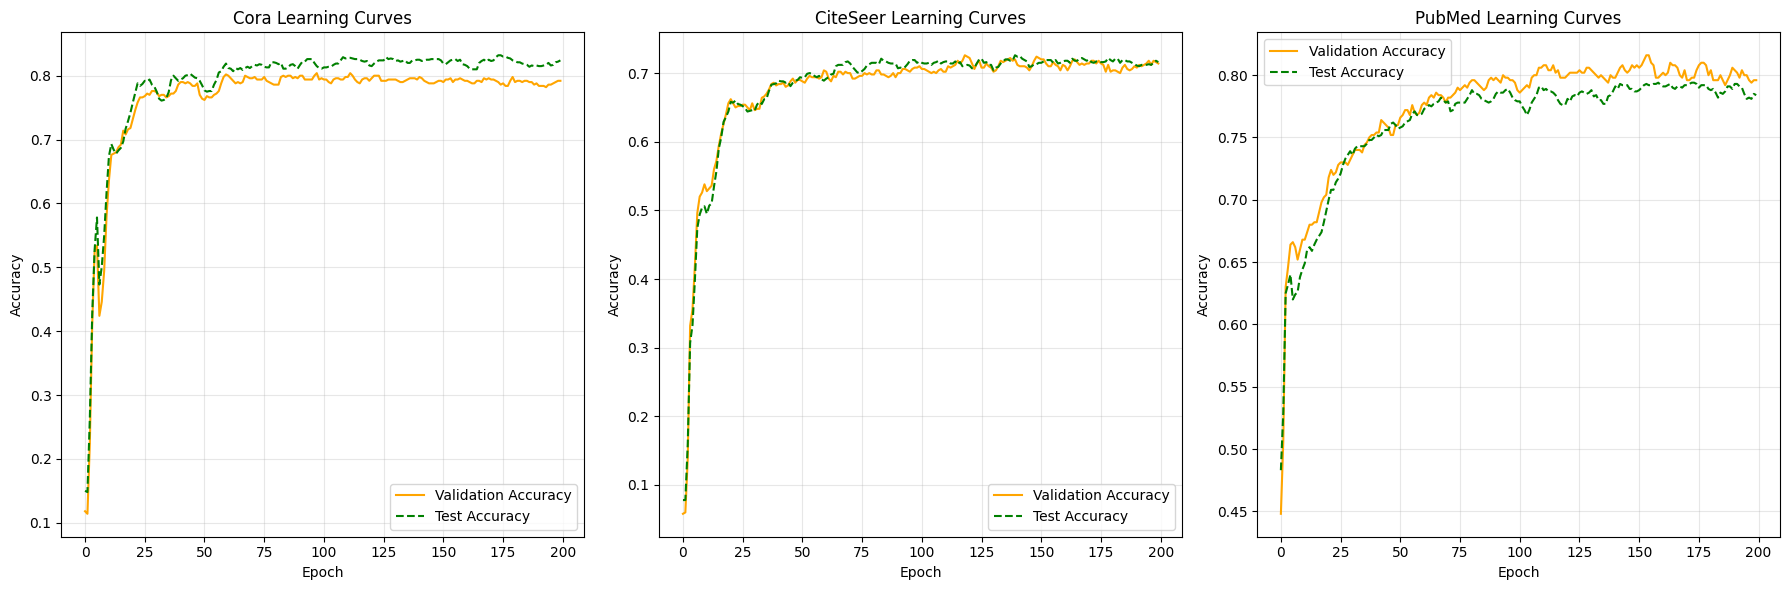

In [64]:
plt.figure(figsize=(18, 6))

for i, name in enumerate(datasets):
    plt.subplot(1, 3, i+1)
    plt.plot(all_history[name]['val_acc'], label='Validation Accuracy', color='orange')
    plt.plot(all_history[name]['test_acc'], label='Test Accuracy', color='green', linestyle='--')
    plt.title(f'{name} Learning Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.savefig('reproduction_curves.png')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


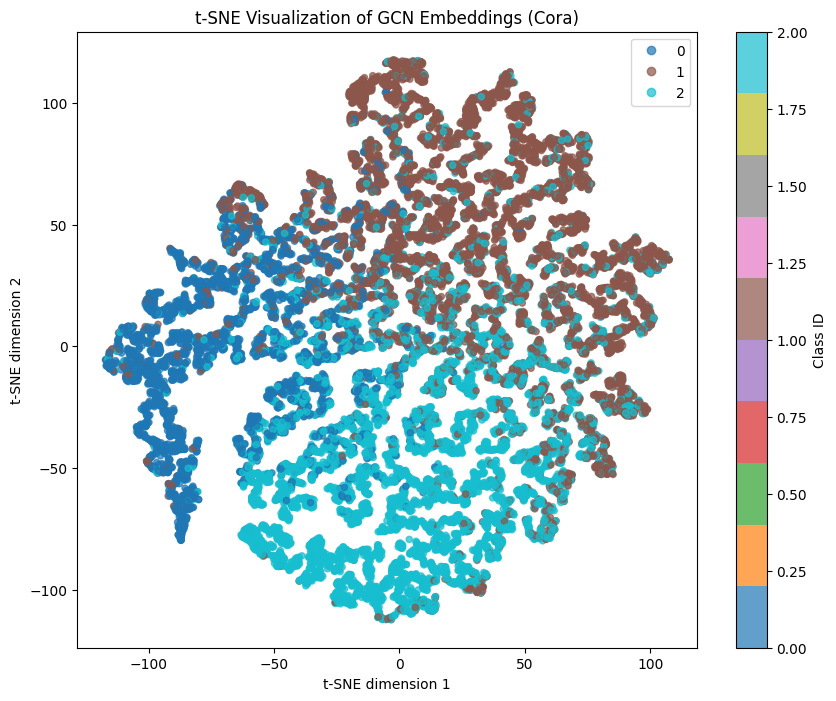

In [65]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def visualize_tsne(model, data):
    model.eval()
    with torch.no_grad():
        # Get the 'hidden' features from the first layer or the output before softmax
        out = model(data)
        # We use the raw logits (before log_softmax) or the embeddings
        h = out.cpu().numpy()
        y = data.y.cpu().numpy()

    # Apply t-SNE
    tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
    h_2d = tsne.fit_transform(h)

    # Plotting
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(h_2d[:, 0], h_2d[:, 1], c=y, cmap='tab10', s=20, alpha=0.7)
    plt.legend(handles=scatter.legend_elements()[0], labels=range(dataset.num_classes))
    plt.title("t-SNE Visualization of GCN Embeddings (Cora)")
    plt.xlabel("t-SNE dimension 1")
    plt.ylabel("t-SNE dimension 2")
    plt.colorbar(label='Class ID')
    plt.savefig('tsne_visualization.png')
    plt.show()

# Run it on the Cora dataset
visualize_tsne(model, data)